In [ ]:
plotTools.setFont('Helvetica', 9)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import scipy 
import numpy as np
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
import pickle 
sns.__version__
import esploco.plotTools as plotTools
import io
import sklearn
plotTools.setFont('Helvetica', 9)
import os
import matplotlib.patches as patches

if 'plots' not in os.listdir():
    os.mkdir('plots')
WTStarvedPalette = {0:sns.color_palette("magma")[5], 24:sns.color_palette("magma")[3], 48:sns.color_palette("magma")[1]}

trhcsch = readEleCsv('TrhCsch_ele.csv')
trhacr = readEleCsv('TrhACRRound2_ele.csv')
r50csch = readEleCsv('R50Csch_ele.csv')
r50acr = readEleCsv('R50ACRRound2_ele.csv')
wt = readEleCsv('w1118dark_ele.csv')

wt.head()

,Light,Genotype,Status,ID,Starvation,Meal Size,Feed Speed,Prefeed Speed,Duringfeed Speed,Postfeed Speed,...,Duration,Latency,Duringfeed Speed Ratio,Perifeed Speed Ratio,Speed,Height,Food Port Occupancy,Ctrl Port Occupancy,Falls,StatusLight
0,Red Light Off,w1118,Ctrl,1,0,-0.170938,0.706844,1.057024,0.252901,3.102424,...,-0.734038,1.506065,-0.666741,1.855002,-0.363593,-2.199607,-0.315626,-0.245454,-0.610883,Ctrl Red Light Off
1,Red Light Off,w1118,Ctrl,11,0,-0.569520,-0.082524,-0.777268,0.136582,-0.100098,...,-0.649236,0.061764,0.687592,1.790039,-0.387833,0.982787,-0.275008,-0.196410,-0.747985,Ctrl Red Light Off
2,Red Light Off,w1118,Ctrl,12,0,-0.589948,-0.424835,0.940104,0.244928,1.318059,...,-0.382149,-0.357610,-0.646143,0.440793,2.036677,0.656099,-0.047152,0.942810,-0.713709,Ctrl Red Light Off
3,Red Light Off,w1118,Ctrl,13,0,-0.613033,-0.498334,-0.555915,0.909149,-0.055695,...,-0.748943,-0.334233,0.778466,0.910027,0.744485,0.573727,-0.260643,-0.132439,-0.439507,Ctrl Red Light Off
4,Red Light Off,w1118,Ctrl,14,0,-0.599038,-0.277949,0.325791,0.123261,0.857275,...,-0.600938,-0.896904,-0.519112,0.657167,0.265724,0.016901,-0.134456,0.748231,-0.747985,Ctrl Red Light Off


In [ ]:
newesults = ele.resultsDf.loc[(ele.resultsDf.feedLogDate != '2023-04-19_15-03-30') & (ele.resultsDf.feedLogDate != '2023-04-20_14-59-27')]

In [ ]:
newresults.feedLogDate.unique()

array(['2023-03-29_15-44-50', '2023-03-30_14-14-19',
       '2023-04-03_14-39-24', '2023-04-18_14-57-52',
       '2023-06-23_15-02-46', '2023-06-24_14-50-48',
       '2023-06-28_14-34-10', '2023-06-28_16-45-59',
       '2023-06-29_15-08-09', '2023-07-01_14-41-02',
       '2023-07-07_17-16-00', '2023-08-11_16-23-56'], dtype=object)

In [ ]:
dark = newresults[['Starved hrs', 'MealSizePerFly_µL',
       'AverageFeedSpeedPerFly_µl/s', 'MeanSpeed120sBeforeFeed_mm/s',
       'MeanSpeedDuringFeed_mm/s', 'MeanSpeed120sAfterFeed_mm/s',
       'MeanMealDurationPerFly_s', 'AverageFeedVolumePerFly_µl', 'AverageFeedCountPerFly',
       'AverageFeedDurationPerFly_min', 'Latency_min',
       'duringBeforeSpeedRatio', 'afterBeforeSpeedRatio',
        'averageSpeed_mm/s', 'yPosition_mm', 'inLeftPort', 'inRightPort','falls', 'feedLogDate']]

renamecolumns = {'Starved hrs': 'Starvation', 
                 'MealSizePerFly_µL': 'Meal Size',
       'AverageFeedSpeedPerFly_µl/s' :'Feed Speed', 
                 'MeanSpeed120sBeforeFeed_mm/s': 'Prefeed Speed',
       'MeanSpeedDuringFeed_mm/s': 'Duringfeed Speed', 
                 'MeanSpeed120sAfterFeed_mm/s': 'Postfeed Speed',
       'MeanMealDurationPerFly_s': 'Meal Duration',
                 'AverageFeedVolumePerFly_µl': 'Volume', 
                 'AverageFeedCountPerFly': 'Count',
       'AverageFeedDurationPerFly_min': 'Duration', 
                 'Latency_min':'Latency',
       'duringBeforeSpeedRatio' : 'Duringfeed Speed Ratio',
                 'afterBeforeSpeedRatio': 'Perifeed Speed Ratio',
        'averageSpeed_mm/s' : 'Speed', 
                 'yPosition_mm': 'Height', 
                 'inLeftPort': 'Food Port Occupancy', 
                 'inRightPort': 'Ctrl Port Occupancy',
                 'falls': 'Falls', 'feedLogDate':'date' }

dark = dark.rename(columns = renamecolumns)
dark = dark.drop(dark.loc[np.isnan(dark['Starvation'])].index, axis = 0)

In [ ]:
wt.Starvation

0       0
1       0
2       0
3       0
4       0
       ..
407    24
408    24
409    24
410    24
411    24
Name: Starvation, Length: 412, dtype: int64

In [ ]:
    
def rugplot(data, suptitle):  
    def format_axes(fig):
        for i, ax in enumerate(fig.axes):
            ax.text(0.5, 0.5, "ax%d" % (i+1), va="center", ha="center")
            ax.tick_params(labelbottom=False, labelleft=False)
    
    fig = plt.figure(figsize = (10, 10));
    gs = GridSpec(3, 3, figure=fig, hspace=0, wspace=0)
    ax1 = fig.add_subplot(gs[0, 1:-1])
    # identical to ax1 = plt.subplot(gs.new_subplotspec((0, 0), colspan=3))
    ax2 = fig.add_subplot(gs[1, 1:-1])
    ax3 = fig.add_subplot(gs[1:2, -1])
    ax4 = fig.add_subplot(gs[-1, 0])
    ax5 = fig.add_subplot(gs[-1, -2])
    
    fig.suptitle("GridSpec");
    # format_axes(fig)
    
    n = 0
    sns.scatterplot(data=data, x="Volume", y = 'Count', hue = 'Starvation', palette=WTStarvedPalette, ax= fig.axes[n], alpha = 0.5);
    sns.rugplot(data=data, x="Volume", y = 'Count', hue = 'Starvation', palette=WTStarvedPalette, ax= fig.axes[n], height=.1, alpha = 0.5);
    fig.axes[n].set_xlim(-2, 6)
    fig.axes[n].set_ylim(-2, 5)

    n = 1
    sns.scatterplot(data=data, x="Volume", y = 'Duration', hue = 'Starvation', palette=WTStarvedPalette, ax= fig.axes[n], alpha = 0.5);
    sns.rugplot(data=data, x="Volume",  y = 'Duration',hue = 'Starvation', palette=WTStarvedPalette, ax= fig.axes[n], height=.1, alpha = 0.5);
    # fig.axes[n].set_ylim(-0.01, 0.17)
    fig.axes[n].set_xlim(-2, 6)
    fig.axes[n].set_ylim(-1.5, 3)

    n = 2
    sns.scatterplot(data=data, x="Feed Speed", y = 'Duration', hue = 'Starvation', palette=WTStarvedPalette, ax= fig.axes[n], alpha = 0.5);
    sns.rugplot(data=data,  x= "Feed Speed", y = 'Duration', hue = 'Starvation', palette=WTStarvedPalette, ax= fig.axes[n], height=.1, alpha = 0.5);
    fig.axes[n].set_xlim(-2, 2.5);
    fig.axes[n].set_ylim(-1.5, 3)

    n = 4
    sns.scatterplot(data=data, x="Volume", y = 'Speed', hue = 'Starvation', palette=WTStarvedPalette, ax= fig.axes[n], alpha = 0.5);
    sns.rugplot(data=data, x="Volume", y = 'Speed', hue = 'Starvation', palette=WTStarvedPalette, ax= fig.axes[n], height=.1, alpha = 0.5);
    fig.axes[n].set_xlim(-2, 6)
    fig.axes[n].set_ylim(-3, 10)

    
    n = 3
    sns.scatterplot(data=data, x="Latency", y = 'Speed', hue = 'Starvation', palette=WTStarvedPalette, ax= fig.axes[n], alpha = 0.5);
    sns.rugplot(data=data, x="Latency", y = 'Speed', hue = 'Starvation', palette=WTStarvedPalette, ax= fig.axes[n], height=.1, alpha = 0.5);
    fig.axes[n].set_ylim(-3, 10)

    fig.suptitle(suptitle)

    for ax in fig.axes:
        ax.get_legend().remove()
        ax.axis('off')
        # ax.set_xticks([])
        # ax.set_yticks([])
        drawRec(ax)
    # fig.tight_layout()
    return fig;

def drawRec(ax):
    ylim = ax.get_ylim()
    yunit = (ylim[1]-ylim[0])/10
    xlim = ax.get_xlim()
    xunit = (xlim[1]-xlim[0])/10
    rect = patches.Rectangle((xlim[0]+ 1.05*xunit, ylim[0] + yunit), xlim[1]- xlim[0]-1.1* xunit, ylim[1] - ylim[0] - yunit , linewidth=1, edgecolor='lightgray', facecolor='none', zorder=-1)
    ax.add_patch(rect)
    return ax


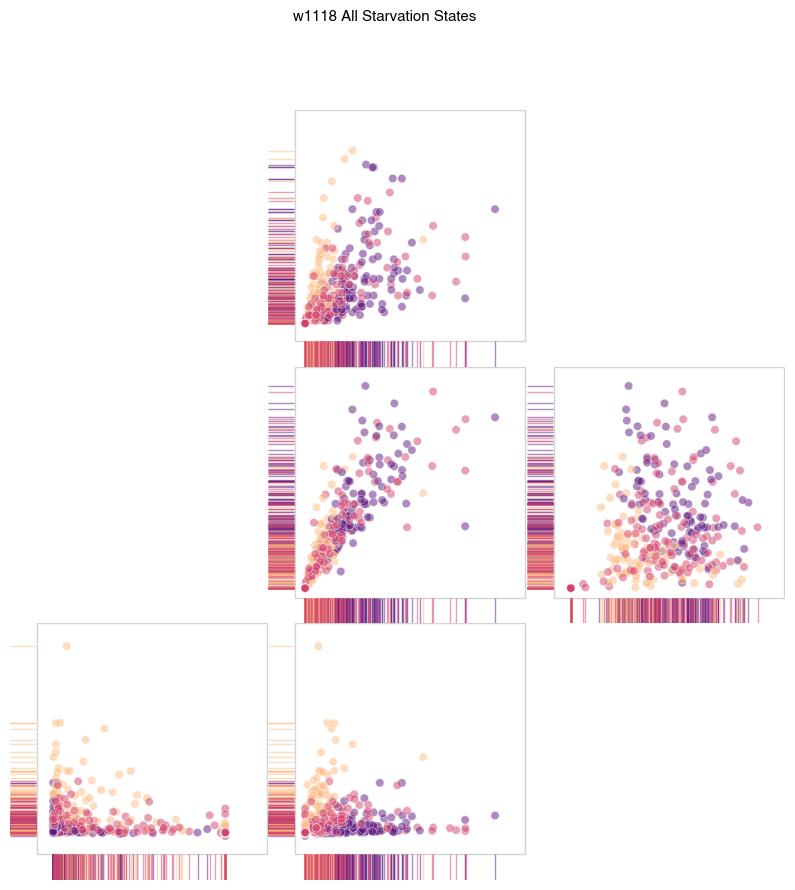

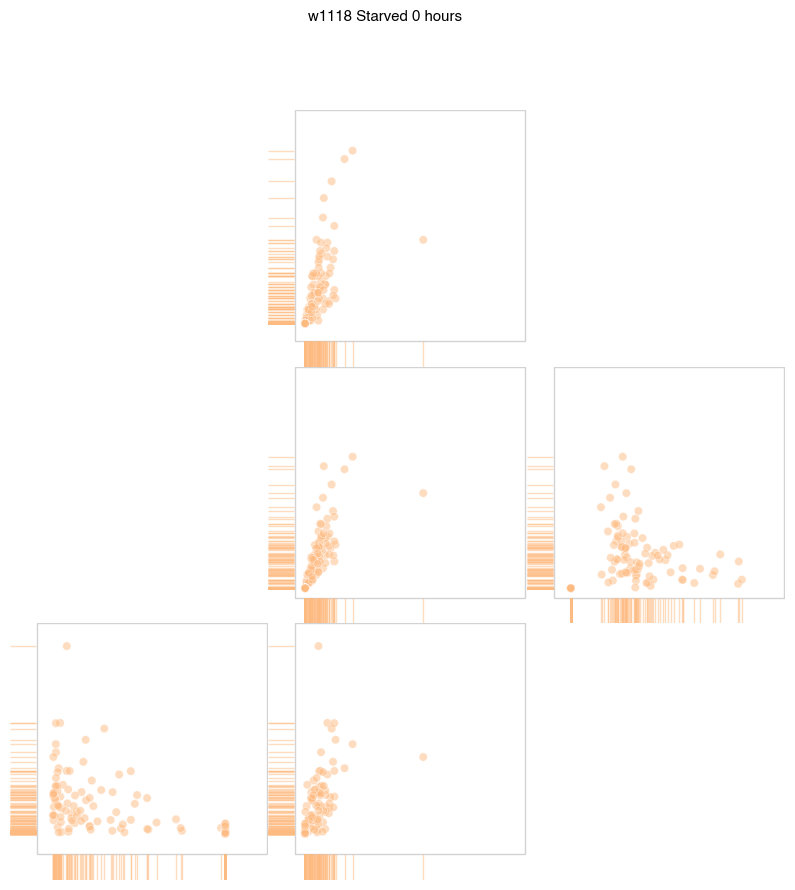

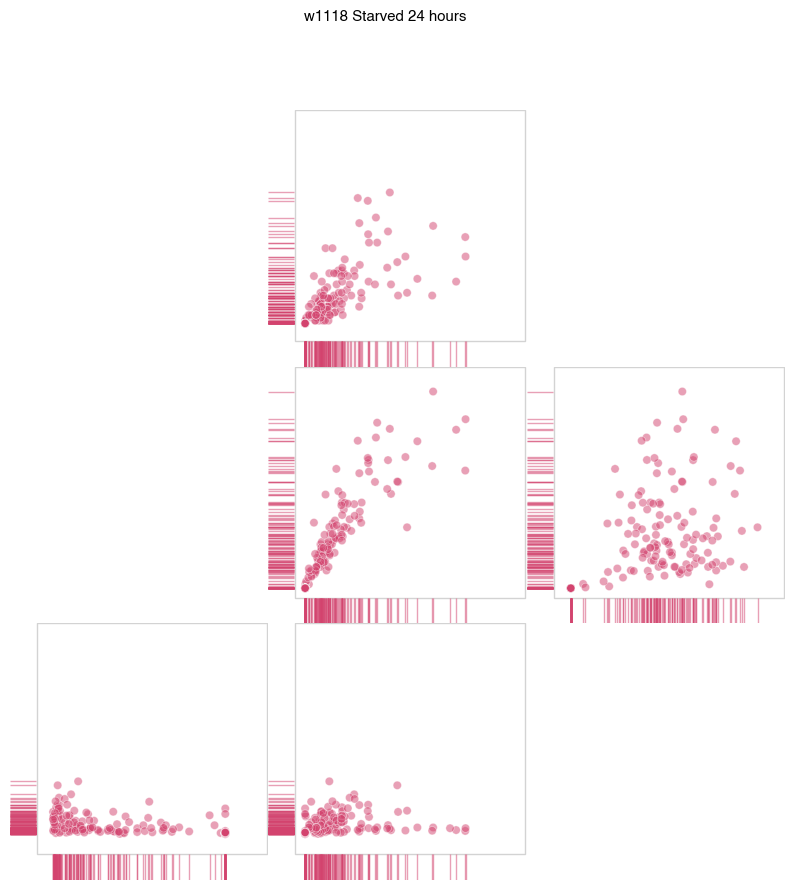

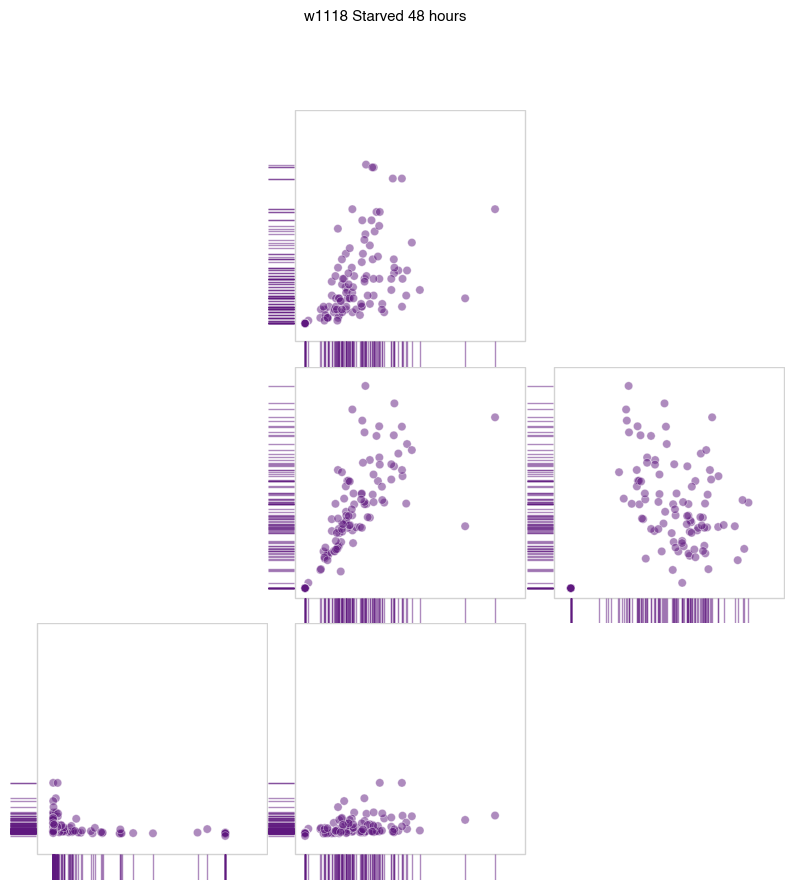

In [ ]:
# rug = rugplot(wt.loc[wt['Starvation']== 0]);
rugWt = rugplot(wt, 'w1118 All Starvation States');
rugWt.savefig('plots/'+'rugWtAll.png', dpi = 300)

rugwt0 = rugplot(wt.loc[wt['Starvation']== 0], 'w1118 Starved 0 hours');
rugwt0.savefig('plots/'+'rugwt0.png', dpi = 300)
rugwt24 = rugplot(wt.loc[wt['Starvation']== 24], 'w1118 Starved 24 hours');
rugwt24.savefig('plots/'+'rugwt24.png', dpi = 300)
rugwt48 = rugplot(wt.loc[wt['Starvation']== 48], 'w1118 Starved 48 hours');
rugwt48.savefig('plots/'+'rugwt48.png', dpi = 300)

In [ ]:
rug0 = rugplot(wt.loc[wt['Starvation']== 0]);
rugWt = rugplot(wt);
rugWt.savefig('plots/'+'rugWtAll.png', dpi = 300)

TypeError: rugplot() missing 1 required positional argument: 'suptitle'

In [ ]:
def confidence_ellipse(x, y, ax, n_std=3.0, plotVector = True, facecolor='none', **kwargs):
    """
    Create a plot of the covariance confidence ellipse of *x* and *y*.

    Parameters
    ----------
    x, y : array-like, shape (n, )
        Input data.

    ax : matplotlib.axes.Axes
        The axes object to draw the ellipse into.

    n_std : float
        The number of standard deviations to determine the ellipse's radiuses.

    **kwargs
        Forwarded to `~matplotlib.patches.Ellipse`

    Returns
    -------
    matplotlib.patches.Ellipse
    """
    import numpy as np
    from matplotlib.patches import Ellipse
    import matplotlib.transforms as transforms
    import matplotlib.pyplot as plt
    if x.size != y.size:
        raise ValueError("x and y must be the same size")

    cov = np.cov(x, y)
    pearson = cov[0, 1]/np.sqrt(cov[0, 0] * cov[1, 1])
    # Using a special case to obtain the eigenvalues of this
    # two-dimensional dataset.
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2,
                      facecolor=facecolor, **kwargs)

    # Calculating the standard deviation of x from
    # the squareroot of the variance and multiplying
    # with the given number of standard deviations.
    scale_x = np.sqrt(cov[0, 0]) * n_std
    mean_x = np.mean(x)

    # calculating the standard deviation of y ...
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_y = np.mean(y)
    transf = transforms.Affine2D() \
        .rotate_deg(45) \
        .scale(scale_x, scale_y) \
        .translate(mean_x, mean_y)
    ellipse.set_transform(transf + ax.transData)
    scale = [scale_x, scale_y]
    return scale, ax.add_patch(ellipse)

def regscatter(data, x, y, ax, n_std = 2, scatter = True, fit_reg = True, plotEllipse = True, showTitle = True, color = 'gray',  **kwargs):
    ax.axvline(c='grey', lw=1)
    ax.axhline(c='grey', lw=1)
    corrResults = scipy.stats.linregress(data[x], data[y])
    if showTitle:
        ax.set_title(y + ' = ' + str(round(corrResults.slope, 2)) +  ' x ' + x  + ' + ' + str(round(corrResults.intercept, 2)) + ' , r = ' + str(round(corrResults.rvalue, 2)))
    # ax.plot(data[x].mean(), data[y].mean(), 'r.', markersize = 10)
    scale = None
    if plotEllipse:
        scale, ellipse = confidence_ellipse(data[x], data[y],  ax, edgecolor= None, facecolor = 'red', alpha = 0.1, n_std = n_std)
    sns.regplot(x = x, y = y, data = data, ax = ax, scatter = scatter, fit_reg= fit_reg, color = color)

    return scale

def plotEigenVectors (data, x, y, ax, scale = [1, 1], plotVs = [0, 1], plotMean = True):
    import numpy as np
    import matplotlib.pyplot as plt
    
    xData = data[x].values
    yData = data[y].values
    xData = np.reshape(xData, (len(xData), 1))
    yData = np.reshape(yData, (len(yData), 1))
    data = np.hstack((xData, yData))
    mu = data.mean(axis=0)
    data = data - mu
    # data = (data - mu)/data.std(axis=0)  # Uncommenting this reproduces mlab.PCA results
    eigenvectors, eigenvalues, V = np.linalg.svd(data.T, full_matrices=False)
    projected_data = np.dot(data, eigenvectors)
    sigma = projected_data.std(axis=0).mean()
    colors = ['steelblue', 'seagreen']
    angles = [0, 0]
    for i in plotVs:
        start, end = mu - scale[i] * 2 * eigenvectors[i], mu + scale[i] * 2 * eigenvectors[i]
        ax.plot([start[0], end[0]], [start[1], end[1]], color = colors[i] ) 
        # print(start)
        angles[i] = angle_between(eigenvectors[i], [[0, 1], [0, 0]])
    ax.set_aspect('equal')
    ax.text(ax.get_xlim()[1]*0.7,ax.get_ylim()[1]*0.9, r'$\Theta = %.2f ^\circ$' % angles[0])
    if plotMean:
        ax.plot(mu[0], mu[1], 'ro')

    return angles

def unit_vector(vector):
    """ Returns the unit vector of the vector.  """
    return vector / np.linalg.norm(vector)

def angle_between(v1, v2):
    """ Returns the angle in radians between vectors 'v1' and 'v2'::

            >>> angle_between((1, 0, 0), (0, 1, 0))
            1.5707963267948966
            >>> angle_between((1, 0, 0), (1, 0, 0))
            0.0
            >>> angle_between((1, 0, 0), (-1, 0, 0))
            3.141592653589793
    """
    v1_u = unit_vector(v1)
    v2_u = unit_vector(v2)
    return 180-np.degrees(np.arccos(np.clip(np.dot(v1_u, v2_u), -1.0, 1.0)))[1]


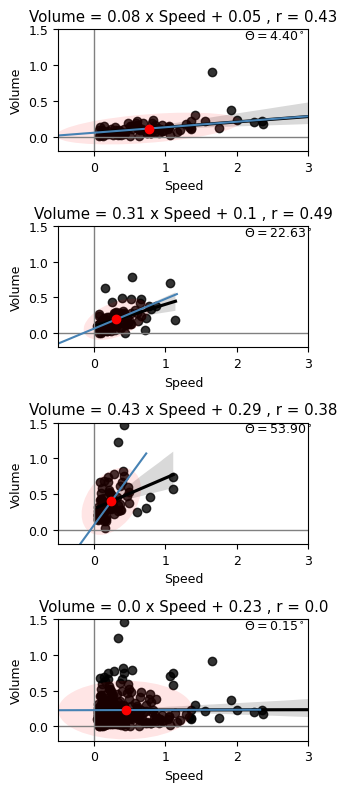

In [ ]:
speedvolume, axes = plt.subplots(4, 1, figsize = [5, 8])
datasets = [dark0, dark24, dark48]
for i in axes:
    i.set_ylim(-0.2, 1.5)
    i.set_xlim(-0.5, 3)

for i in range(len(datasets)):
    scale = regscatter(datasets[i], x = 'Speed', y = 'Volume', ax = axes[i], color = 'k')
    angles = plotEigenVectors(datasets[i], x = 'Speed', y = 'Volume', ax = axes[i], scale = scale, plotVs = [0])
scale = regscatter(dark, x = 'Speed', y = 'Volume', ax = axes[3], color = 'k')
angles = plotEigenVectors(dark, x = 'Speed', y = 'Volume', ax = axes[3], scale = scale, plotVs = [0])

speedvolume.tight_layout()
speedvolume.savefig('speedvolumeellipses.png', dpi = 300)




NameError: name 'dark0' is not defined

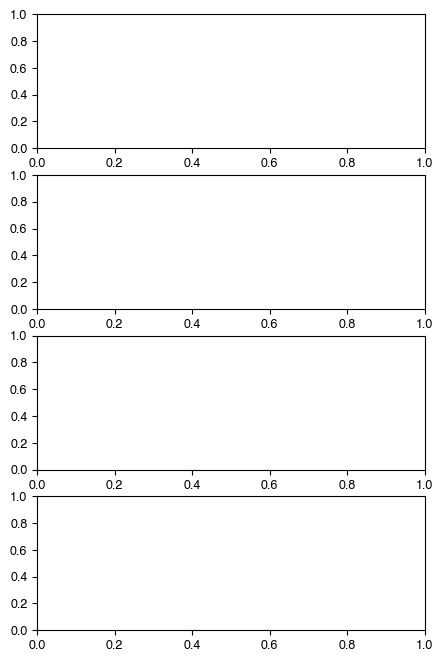

In [ ]:
durationvolume, axes = plt.subplots(4, 1, figsize = [5, 8])
datasets = [dark0, dark24, dark48]

for i in axes:
    i.set_ylim(-0.2, 1.2)
    i.set_xlim(-0.5, 7)

for i in range(len(datasets)):
    scale = regscatter(datasets[i], x = 'Duration', y = 'Volume', ax = axes[i], color = 'k')
    angles = plotEigenVectors(datasets[i], x = 'Duration', y = 'Volume', ax = axes[i], scale = scale, plotVs = [0])
scale = regscatter(dark, x = 'Duration', y = 'Volume', ax = axes[3], color = 'k')
angles = plotEigenVectors(dark, x = 'Duration', y = 'Volume', ax = axes[3], scale = scale, plotVs = [0])

durationvolume.tight_layout()
durationvolume.savefig('durationvolumeellipses.png', dpi = 300)




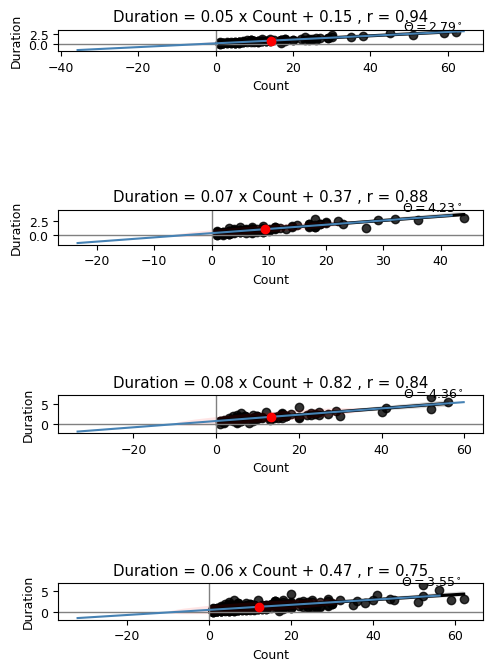

In [ ]:
countduration, axes = plt.subplots(4, 1, figsize = [5, 8])
datasets = [dark0, dark24, dark48]
# for i in axes:
    # i.set_ylim(-0.2, 1.5)
    # i.set_xlim(-0.5, 3)

for i in range(len(datasets)):
    scale = regscatter(datasets[i], x = 'Count', y = 'Duration', ax = axes[i], color = 'k')
    angles = plotEigenVectors(datasets[i], x = 'Count', y = 'Duration', ax = axes[i], scale = scale, plotVs = [0])
scale = regscatter(dark, x = 'Count', y = 'Duration', ax = axes[3], color = 'k')
angles = plotEigenVectors(dark, x = 'Count', y = 'Duration', ax = axes[3], scale = scale, plotVs = [0])

countduration.tight_layout()
countduration.savefig('countdurationellipses.png', dpi = 300)



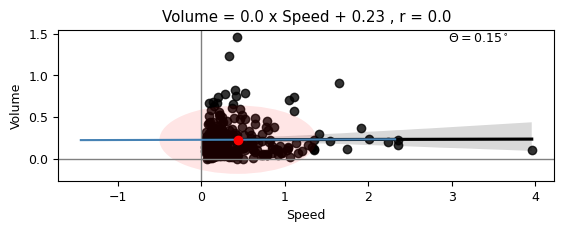

In [ ]:
fig, axes = plt.subplots(1, 1)
scale = regscatter(dark, x = 'Speed', y = 'Volume', ax = axes, color = 'k')
angles = plotEigenVectors(dark, x = 'Speed', y = 'Volume', ax = axes, scale = scale, plotVs = [0])


<AxesSubplot:xlabel='AverageFeedVolumePerFly_µl', ylabel='averageSpeed_mm/s'>

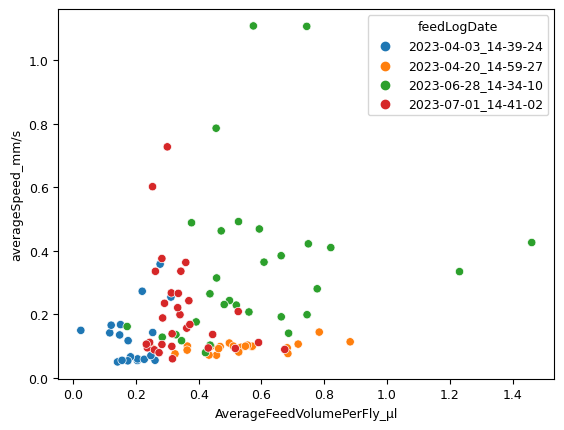

In [ ]:
sns.scatterplot(ele.resultsDf.loc[ele.resultsDf['Starved hrs']==48], x = 'AverageFeedVolumePerFly_µl', y = 'averageSpeed_mm/s', hue = 'feedLogDate')

ValueError: not enough values to unpack (expected 2, got 0)

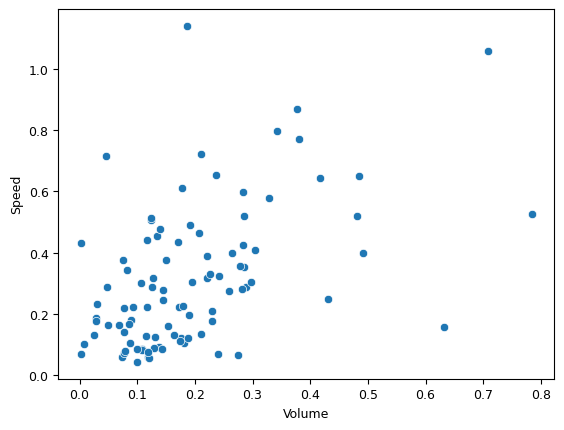

In [ ]:
speedvolume = sns.scatterplot(dark24, y = 'Speed', x = 'Volume')
speedvolume.set_xlim('')

<AxesSubplot:xlabel='Volume', ylabel='Speed'>

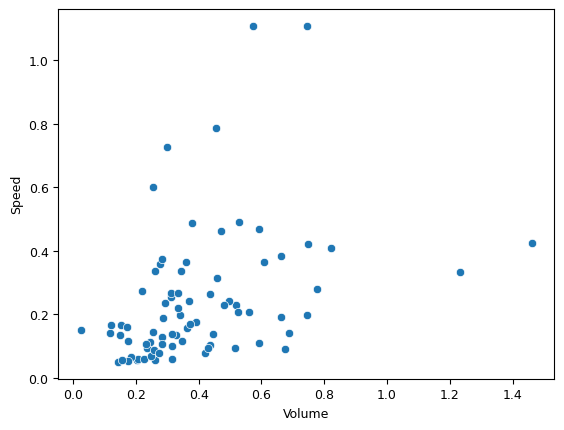

In [ ]:
sns.scatterplot(dark48, y = 'Speed', x = 'Volume')

In [ ]:
print('correlation with starved hrs')
rtableStarved = pd.DataFrame({})
for i in range(0, len(dark.columns)):
    result = scipy.stats.linregress(dark.loc[~np.isnan(dark.iloc[:, i])].iloc[:, i], dark.loc[~np.isnan(dark.iloc[:, i])].iloc[:, 0])
    subtable = pd.DataFrame({'Factor': [dark.columns[i]], 'rsq': [result.rvalue**2], 'p': [result.pvalue]})
    rtableStarved  = pd.concat([rtableStarved, subtable])
rtableStarved = rtableStarved.sort_values(by = 'rsq', ascending=False).reset_index(drop = True)
display(rtableStarved)


correlation with starved hrs


,Factor,rsq,p
0,Starvation,1.000000,0.000000e+00
1,Volume,0.306299,1.993891e-22
2,Speed,0.200590,2.491931e-14
3,Meal Size,0.198983,3.247908e-14
4,Meal Duration,0.188048,1.945148e-13
5,Duration,0.187650,2.075129e-13
6,Duringfeed Speed,0.160350,1.644285e-11
7,Feed Speed,0.139969,3.964930e-10
8,Ctrl Port Occupancy,0.135119,8.375358e-10
9,Postfeed Speed,0.087667,1.063493e-06


In [ ]:
dark

,Starvation,Meal Size,Feed Speed,Prefeed Speed,Duringfeed Speed,Postfeed Speed,Meal Duration,Volume,Count,Duration,Latency,Duringfeed Speed Ratio,Perifeed Speed Ratio,Speed,Height,Food Port Occupancy,Ctrl Port Occupancy,Falls
0,0.0,0.017590,0.002850,2.355302,0.419120,3.275484,5.973750,0.035179,2.0,0.199125,117.030500,0.177948,1.390686,0.167022,1.834326,0.320228,0.022923,6.0
1,0.0,0.005274,0.001689,0.538224,0.390943,0.734650,3.122000,0.031643,6.0,0.312200,47.245100,0.726357,1.364951,0.157038,11.216739,0.548069,0.086830,2.0
2,0.0,0.004643,0.001186,2.239479,0.417189,1.859795,2.864286,0.064997,14.0,0.668333,26.981900,0.186288,0.830459,1.155604,10.253588,1.826202,1.571270,3.0
3,0.0,0.003929,0.001078,0.757499,0.578090,0.769878,3.585000,0.011788,3.0,0.179250,28.111417,0.763155,1.016341,0.623398,10.010737,0.628647,0.170186,11.0
4,0.0,0.004362,0.001402,1.630931,0.387716,1.494216,2.510667,0.039256,9.0,0.376600,0.924467,0.237727,0.916173,0.426214,8.369090,1.336482,1.317727,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307,24.0,0.006671,0.001538,1.238680,0.759596,1.508421,3.563714,0.046694,7.0,0.415767,67.025517,0.613230,1.217765,0.714169,6.517744,0.864129,0.188941,65.0
308,24.0,0.027230,0.001612,0.726712,0.755478,2.716660,8.015833,0.081690,3.0,0.400792,0.021900,1.039584,3.738291,0.343363,4.987760,0.518894,0.000000,55.0
309,24.0,0.028407,0.002655,0.595102,0.193340,0.395551,10.004500,0.085220,3.0,0.500225,77.045133,0.324885,0.664678,0.169064,5.147584,0.574465,0.000000,30.0
310,24.0,0.004900,0.001191,0.598313,0.200042,0.305516,4.597750,0.029403,6.0,0.459775,27.567433,0.334344,0.510629,0.178870,6.375835,0.694637,0.000000,96.0


In [ ]:
rtableVolume = pd.DataFrame({})

for i in range(0, len(dark.columns)):
    result = scipy.stats.linregress(dark.loc[~np.isnan(dark.iloc[:, i])].iloc[:, i], dark.loc[~np.isnan(dark.iloc[:, i])].iloc[:, 7])
    subtable = pd.DataFrame({'Factor': [dark.columns[i]], 'rsq': [result.rvalue**2], 'p': [result.pvalue]})
    rtableVolume  = pd.concat([rtableVolume, subtable])
rtableVolume = rtableVolume.sort_values(by = 'rsq', ascending=False).reset_index(drop = True)
display(rtableVolume)


,Factor,rsq,p
0,Volume,1.000000,0.000000e+00
1,Duration,0.575741,2.539195e-50
2,Starvation,0.306299,1.993891e-22
3,Count,0.177360,1.095315e-12
4,Latency,0.140597,3.597975e-10
5,Meal Size,0.098557,2.114095e-07
6,Feed Speed,0.080987,2.847736e-06
7,Food Port Occupancy,0.042362,8.037283e-04
8,Meal Duration,0.028099,6.536699e-03
9,Duringfeed Speed Ratio,0.010744,9.407412e-02


In [ ]:
dark.columns

Index(['Starvation', 'Meal Size', 'Feed Speed', 'Prefeed Speed',
       'Duringfeed Speed', 'Postfeed Speed', 'Meal Duration', 'Volume',
       'Count', 'Duration', 'Latency', 'Duringfeed Speed Ratio',
       'Perifeed Speed Ratio', 'Speed', 'Height', 'Food Port Occupancy',
       'Ctrl Port Occupancy', 'Falls'],
      dtype='object')

0                 Starvation
1                     Volume
2                      Speed
3                  Meal Size
4              Meal Duration
5                   Duration
6           Duringfeed Speed
7                 Feed Speed
8        Ctrl Port Occupancy
9             Postfeed Speed
10      Perifeed Speed Ratio
11                   Latency
12             Prefeed Speed
13                    Height
14                     Falls
15    Duringfeed Speed Ratio
16       Food Port Occupancy
17                     Count
Name: Factor, dtype: object
0                     Volume
1                   Duration
2                 Starvation
3                      Count
4                    Latency
5                  Meal Size
6                 Feed Speed
7        Food Port Occupancy
8              Meal Duration
9     Duringfeed Speed Ratio
10          Duringfeed Speed
11                     Falls
12      Perifeed Speed Ratio
13                    Height
14       Ctrl Port Occupancy
15            P

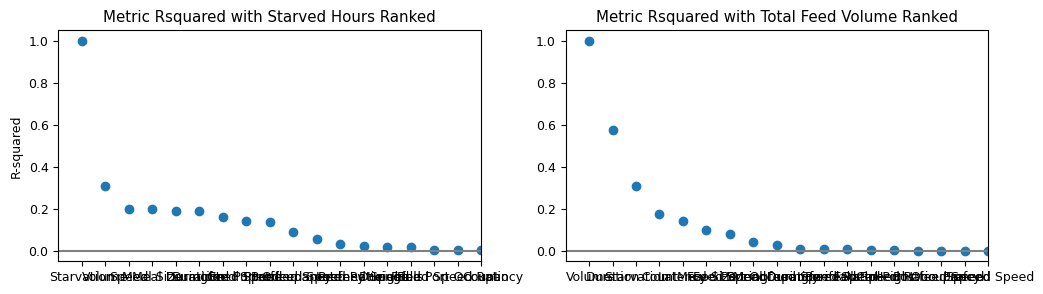

In [ ]:
f, axes = plt.subplots(1, 2, figsize = (12, 3))



axes[0].plot(rtableStarved['Factor'], rtableStarved['rsq'], 'o')
axes[0].plot([-1, 17], [0, 0], 'gray')
axes[0].set_xlim([-1, 17])
# axes[0].set_xticks(rtableStarved['Factor'], rtableStarved['Factor'], rotation=45, ha = 'right');
axes[0].set_title('Metric Rsquared with Starved Hours Ranked')
axes[0].set_ylabel('R-squared')
print(rtableStarved['Factor'])

axes[1].plot(rtableVolume['Factor'], rtableVolume['rsq'], 'o')
axes[1].plot([-1, 17], [0, 0], 'gray')
axes[1].set_xlim([-1, 17])
# axes[1].set_xticks(rtableVolume['Factor'], rtableVolume['Factor'], rrotation=45, ha = 'right');
axes[1].set_title('Metric Rsquared with Total Feed Volume Ranked')

plt.savefig('plots/RsquaredwithStarvedandVolume.png', dpi = 300)
print(rtableVolume['Factor'])

In [ ]:
uniqueStarved = dark['Starved hrs'].unique()
f, axes = plt.subplots(1, 3, figsize = (15, 3))

rtableVolumeSub = list()
for j in range(len(uniqueStarved)):
    subset = dark.loc[dark['Starved hrs']== uniqueStarved[j]]
    rtableVolumeSub.append(pd.DataFrame({'Factor' : [], 'rsq' : [], 'p' : []}))
    for i in range(1, len(subset.columns)):
        result = scipy.stats.linregress(subset.loc[~np.isnan(subset.iloc[:, i])].iloc[:, i], subset.loc[~np.isnan(subset.iloc[:, i])].iloc[:, 1])
        subtable = pd.DataFrame({'Factor': [subset.columns[i]], 'rsq': [result.rvalue**2], 'p': [result.pvalue]})
        rtableVolumeSub[j]  = pd.concat([rtableVolumeSub[j], subtable])
    rtableVolumeSub[j] = rtableVolumeSub[j].sort_values(by = 'rsq', ascending=False).reset_index(drop = True)
    axes[j].plot(rtableVolumeSub[j]['Factor'][1:], rtableVolumeSub[j]['rsq'][1:], 'o')
    axes[j].set_xlim([-1, 17])
    axes[j].set_ylim([-0.06, 0.7])
    axes[j].set_xticks(rtableVolumeSub[j]['Factor'], rtableVolumeSub[j]['Factor'], rotation=45, ha = 'right');
    axes[j].set_title('Starved ' + str(uniqueStarved[j]) + 'hrs')
fig.suptitle('Metric Rsquared with Total Feed Volume Ranked')
axes[0].set_ylabel('R-squared')

plt.savefig('plots/RsquaredByStarved.png', dpi = 300)




KeyError: 'Starved hrs'

In [ ]:
rtableVolumeSub[0] = rtableVolumeSub[0].set_index('Factor')

NameError: name 'rtableVolumeSub' is not defined

In [ ]:
rtableVolumeSub[1] = rtableVolumeSub[1].set_index('Factor').reindex(index = rtableVolumeSub[0].index)

In [ ]:
rtableVolumeSub[2] = rtableVolumeSub[2].set_index('Factor').reindex(index = rtableVolumeSub[0].index)

In [ ]:
palette = {0: 'gray', 1:'pink', 2:'red'}
plt.figure(figsize = (5, 4))
for i in range(3):
    plt.plot(rtableVolumeSub[i].index[1:], rtableVolumeSub[i].rsq[1:],'o', color = palette[i], label = uniqueStarved[i])
    plt.xlim([-1, 12])
    plt.ylim([-0.06, 0.7])
    plt.title('Metric Rsquared with Total Feed Volume Ranked')
plt.ylabel('R-squared')
plt.xticks(rtableVolumeSub[0].index[1:], rtableVolumeSub[0].index[1:], rotation=45, ha = 'right');
plt.legend()
plt.savefig('plots/RsquaredOrderedBy0hrStarved.png', dpi = 300)


NameError: name 'rtableVolumeSub' is not defined

<Figure size 500x400 with 0 Axes>

In [ ]:
palette = {0: 'gray', 1:'pink', 2:'red'}
plt.figure(figsize = (5, 4))
for i in range(2):
    plt.bar(np.arange(12)+i*0.5, rtableVolumeSub[i+1].rsq[1:] - rtableVolumeSub[i].rsq[1:], 
            width = 0.4, color = palette[i+1], label = uniqueStarved[i+1])
    plt.xlim([-1, 12])
#     plt.ylim([-0.06, 0.7])
    plt.title('Metric Rsquared Delta Compared to Fed')
plt.xticks(np.arange(12)+i*0.2, rtableVolumeSub[0].index[1:], rotation=45, ha = 'right');
plt.legend()
plt.ylabel('Delta R-Squared')
plt.savefig('plots/DeltaRSquared.png', dpi = 300)


NameError: name 'rtableVolumeSub' is not defined

<Figure size 500x400 with 0 Axes>

In [ ]:
len(rtableVolumeSub[0])

13